In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

file_name = r"C:\Users\Mariam\Downloads\277460_6a2b37b3b3b81_1781217203 (1).csv"
df = pd.read_csv(file_name)

df.head()

,supplier_record_id,supplier_id,supplier_name,business_name,city,delivery_date,supply_category,supplier_status,purchase_amount,data_source,created_by,late_days,defect_rate_pct,quality_rating,orders_count,contract_active,store_id,sku,issue_reason
0,SUPP-100503,SUP-179,Karim Kamal,DailyNeeds,luxor,2025-01-22,BAKERY,active,38729.30,Excel Upload,agent,78.0,59.09,5.0,30,Yes,STORE-30,SKU-78520,NaN
1,SUPP-100164,SUP-164,Ali Hassan,DailyNeeds,Gizaa,2025-05-16,Beverages,Blocked,21159.75,Mobile App,system,81.0,1000000.00,5.0,1,Yes,STORE-79,SKU-85791,Wrong data entry
2,SUPP-100577,SUP-167,Nada Ibrahim,DailyNeeds,TANTA,2025-03-28,Household,Active,17448.01,ERP,import_job,82.0,66.32,5.0,2,No,STORE-55,SKU-23180,NaN
3,SUPP-100345,SUP-167,Youssef Adel,DailyNeeds,Cair0,05-29-2025,NaN,Blocked,40043.69,Call Center,admin,4.0,75.26,5.0,50,No,STORE-86,SKU-13922,Wrong data entry
4,SUPP-100645,SUP-212,Nour Samir,DailyNeeds,MANSOURA,23/10/2025,Bakery,Under Review,32245.59,Website,import_job,56.0,56.50,3.0,2,Yes,STORE-32,SKU-65946,missing documents


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 843 entries, 0 to 842
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   supplier_record_id  843 non-null    object 
 1   supplier_id         843 non-null    object 
 2   supplier_name       823 non-null    object 
 3   business_name       843 non-null    object 
 4   city                820 non-null    object 
 5   delivery_date       843 non-null    object 
 6   supply_category     813 non-null    object 
 7   supplier_status     821 non-null    object 
 8   purchase_amount     843 non-null    float64
 9   data_source         818 non-null    object 
 10  created_by          796 non-null    object 
 11  late_days           823 non-null    float64
 12  defect_rate_pct     843 non-null    float64
 13  quality_rating      818 non-null    float64
 14  orders_count        843 non-null    int64  
 15  contract_active     843 non-null    object 
 16  store_id

In [5]:
df.describe()

,purchase_amount,late_days,defect_rate_pct,quality_rating,orders_count
count,843.000000,823.000000,843.000000,818.000000,843.000000
mean,25745.407117,46.979344,7164.896928,3.727384,7719.233689
std,26964.010575,26.485470,80502.590569,1.142378,85808.740401
min,-999.000000,0.000000,-999.000000,1.000000,-999.000000
25%,13516.865000,23.500000,24.130000,3.000000,2.000000
50%,24137.060000,49.000000,50.220000,4.000000,5.000000
75%,36702.345000,70.000000,74.070000,5.000000,20.000000
max,500000.000000,89.000000,1000000.000000,5.000000,1000000.000000


In [7]:
## checking the null values 
df.isnull().sum()

supplier_record_id      0
supplier_id             0
supplier_name          20
business_name           0
city                   23
delivery_date           0
supply_category        30
supplier_status        22
purchase_amount         0
data_source            25
created_by             47
late_days              20
defect_rate_pct         0
quality_rating         25
orders_count            0
contract_active         0
store_id                0
sku                     0
issue_reason          494
dtype: int64

In [9]:
print("Original shape:", df.shape)

Original shape: (843, 19)


In [11]:
# --- DATA CLEANING ---
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

After removing duplicates: (810, 19)


### CITY COLUMN

In [15]:
##. تنظيف أسماء المدن
df['city'].count()

788

In [17]:
df['city'].value_counts()

city
zagazig       23
اسكندرية      21
ASYUT         21
LUXOR         20
cairo         20
              ..
 Cairo         1
gizaa          1
 ISMAILIA      1
 TANTA         1
 aswan         1
Name: count, Length: 71, dtype: int64

#### There is 71 different words in city and its not right 

In [20]:
## function to bound each city to one global word for it

def clean_city_advanced(city):
    if pd.isna(city):
        return 'Unknown'
    
    # تحويل النص إلى نصوص صغيرة (Lowercase) وإزالة المسافات من الأطراف لتوحيد المقارنة
    city_clean = str(city).strip().lower()
    
    # قاموس لتوحيد كل الأشكال الممكنة (عربي، إنجليزي مغلوط، رموز) إلى اسم موحد
    city_mapping = {
        # القاهرة
        'cairo': 'Cairo', 'cair0': 'Cairo', 'القاهرة': 'Cairo',
        # الجيزة
        'giza': 'Giza', 'gizaa': 'Giza', 'الجيزة': 'Giza',
        # طنطا
        'tanta': 'Tanta',
        # الأقصر
        'luxor': 'Luxor',
        # المنصورة
        'mansoura': 'Mansoura', 'el mansoura': 'Mansoura', 'el-mansoura': 'Mansoura',
        # أسوان
        'aswan': 'Aswan',
        # السويس
        'suez': 'Suez',
        # بني سويf
        'beni-suef': 'Beni Suef', 'beni suef': 'Beni Suef', 'beni_suef': 'Beni Suef', 
        'بني سويف': 'Beni Suef', 'بني_سويف': 'Beni Suef', 'بني-سويف': 'Beni Suef',
        # قنا
        'qena': 'Qena',
        # الإسكندرية
        'alexandria': 'Alexandria', 'alex': 'Alexandria', 'اسكندرية': 'Alexandria',
        # الإسماعيلية
        'ismailia': 'Ismailia',
        # أسيوط
        'assiut': 'Assiut', 'asyut': 'Assiut', 'أسيوط': 'Assiut',
        # المنيا
        'minya': 'Minya',
        # الزقازيق
        'zagazig': 'Zagazig',
        # الفيوم
        'fayoum': 'Fayoum'
    }
    
    # إرجاع الاسم النظيف الموحد، وإذا كانت هناك مدينة جديدة يرجعها كـ Capitalized
    return city_mapping.get(city_clean, str(city).strip().capitalize())

# تطبيق الدالة المحدثة
df['city'] = df['city'].apply(clean_city_advanced)

C:\Users\Mariam\AppData\Local\Temp\ipykernel_46620\548058116.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['city'] = df['city'].apply(clean_city_advanced)


In [22]:
df['city']

0          Luxor
1           Giza
2          Tanta
3          Cairo
4       Mansoura
         ...    
837        Minya
838         Giza
839       Assiut
840    Beni Suef
841       Assiut
Name: city, Length: 810, dtype: object

In [24]:
df['city'].nunique()

16

### The 71 different city became 16 , now it makes sense and more accurate!

### supply_category COLUMN

In [28]:
df['supply_category'].value_counts

<bound method IndexOpsMixin.value_counts of 0         BAKERY
1      Beverages
2      Household
3            NaN
4         Bakery
         ...    
837        Dairy
838       Bakery
839       Bakery
840    Beverages
841        Dairy
Name: supply_category, Length: 810, dtype: object>

### There is some of them contain capital letters while other have small letters even it's the same word

In [31]:
df['supply_category'] = df['supply_category'].astype(str).str.strip().str.capitalize()
df['supply_category'] = df['supply_category'].replace('Nan', 'Unknown')

## date COLUMN

In [34]:
# ── 4. Fix Negative / Invalid Numeric Values ──────────────────────────────────
# Replace negative values with NaN (they are invalid)
df['purchase_amount'] = df['purchase_amount'].apply(lambda x: np.nan if x < 0 else x)
df['orders_count']    = df['orders_count'].apply(lambda x: np.nan if x < 0 else x)
df['defect_rate_pct']    = df['defect_rate_pct'].apply(lambda x: np.nan if x < 0 else x)

In [36]:
# Convert mixed date formats (YYYY-MM-DD and MM-DD-YYYY) into a uniform datetime format
df['delivery_date'] = pd.to_datetime(df['delivery_date'], errors='coerce')
# Fill missing dates using Forward Fill (ffill) strategy
df['delivery_date'] = df['delivery_date'].ffill() 
print("✔ Delivery dates standardized.")

✔ Delivery dates standardized.


In [38]:
# Defect rate cannot logically exceed 100%. Extreme values (e.g., 1000000) are treated as data entry errors.
df.loc[df['defect_rate_pct'] > 100, 'defect_rate_pct'] = np.nan
# Impute outliers and missing values with the median of the column
df['defect_rate_pct'] = df['defect_rate_pct'].fillna(df['defect_rate_pct'].median())
print("✔ Defect rate outliers handled.")

✔ Defect rate outliers handled.


In [40]:
df['supplier_status'] = df['supplier_status'].astype(str).str.strip().str.capitalize()
df['issue_reason'] = df['issue_reason'].fillna('No Issue Mentioned').astype(str).str.strip()
df['data_source'] = df['data_source'].fillna('Unknown').astype(str).str.strip()
print("✔ Categorical statuses and missing reasons handled.")

✔ Categorical statuses and missing reasons handled.


In [42]:
df.isnull().sum()

supplier_record_id     0
supplier_id            0
supplier_name         20
business_name          0
city                   0
delivery_date          0
supply_category        0
supplier_status        0
purchase_amount        5
data_source            0
created_by            42
late_days             19
defect_rate_pct        0
quality_rating        24
orders_count           5
contract_active        0
store_id               0
sku                    0
issue_reason           0
dtype: int64

In [44]:
df.describe()

,delivery_date,purchase_amount,late_days,defect_rate_pct,quality_rating,orders_count
count,810,805.000000,791.000000,810.000000,786.000000,805.000000
mean,2025-07-08 00:39:06.666666752,25921.424981,47.139064,49.169802,3.741730,6844.693168
min,2025-01-01 00:00:00,0.000000,0.000000,0.000000,1.000000,0.000000
25%,2025-04-10 00:00:00,13527.140000,24.000000,24.237500,3.000000,2.000000
50%,2025-07-06 00:00:00,24238.390000,49.000000,50.040000,4.000000,5.000000
75%,2025-10-07 18:00:00,36749.780000,70.000000,73.532500,5.000000,20.000000
max,2026-01-01 00:00:00,500000.000000,89.000000,99.980000,5.000000,1000000.000000
std,NaN,27392.231604,26.444848,28.960237,1.139097,80516.678740


In [46]:
# ── 5. Fill Missing Values ────────────────────────────────────────────────────
# Text columns → fill with 'Unknown' or 'No Issue'
df['supplier_name']   = df['supplier_name'].fillna('Unknown')
df['city']            = df['city'].fillna('Unknown')
df['supply_category'] = df['supply_category'].fillna('Unknown')
df['supplier_status'] = df['supplier_status'].fillna('Unknown')
df['data_source']     = df['data_source'].fillna('Unknown')
df['created_by']      = df['created_by'].fillna('Unknown')
df['issue_reason']    = df['issue_reason'].fillna('No Issue')

In [48]:

# Numeric columns → fill with median
df['late_days']       = df['late_days'].fillna(df['late_days'].median())
df['quality_rating']  = df['quality_rating'].fillna(df['quality_rating'].median())
df['purchase_amount'] = df['purchase_amount'].fillna(df['purchase_amount'].median())
df['orders_count']    = df['orders_count'].fillna(df['orders_count'].median())


In [50]:
# ── 7. Final Check ────────────────────────────────────────────────────────────
print("\nFinal shape:", df.shape)
print("\nMissing values after cleaning:")
print(df.isnull().sum())


Final shape: (810, 19)

Missing values after cleaning:
supplier_record_id    0
supplier_id           0
supplier_name         0
business_name         0
city                  0
delivery_date         0
supply_category       0
supplier_status       0
purchase_amount       0
data_source           0
created_by            0
late_days             0
defect_rate_pct       0
quality_rating        0
orders_count          0
contract_active       0
store_id              0
sku                   0
issue_reason          0
dtype: int64


In [57]:
df.to_csv(r'C:\Users\Mariam\Downloads\cleaned_supplier_data.csv', index=False, encoding='utf-8-sig')
print("✅ File saved to Downloads!")

✅ File saved to Downloads!


### Visualization

C:\Users\Mariam\AppData\Local\Temp\ipykernel_46620\3814417521.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='supplier_status', palette='Set2', order=df['supplier_status'].value_counts().index)


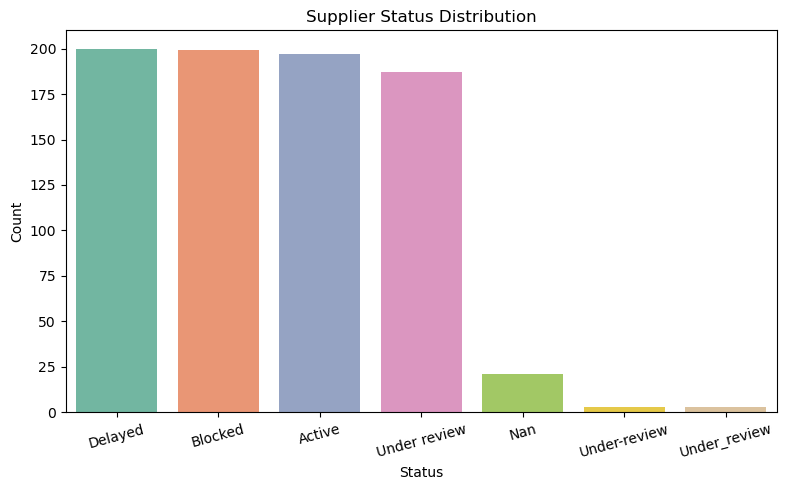

In [61]:
## Supplier Status Distribution
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='supplier_status', palette='Set2', order=df['supplier_status'].value_counts().index)
plt.title('Supplier Status Distribution')
plt.xlabel('Status')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

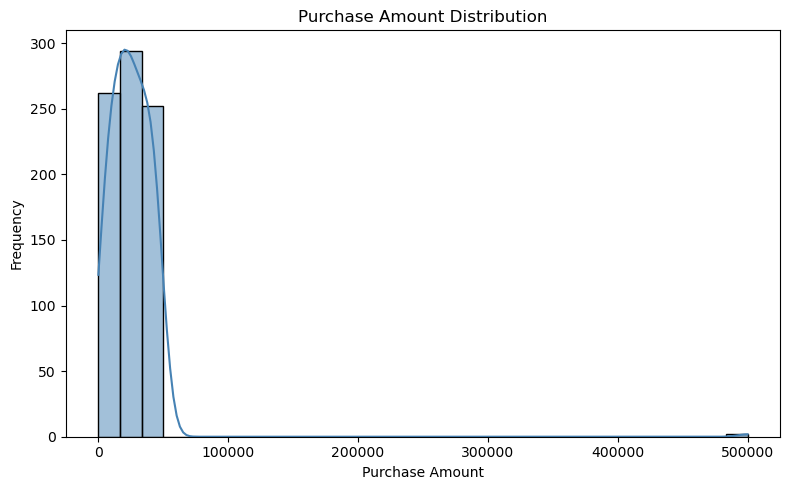

In [63]:
## Purchase Amount Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['purchase_amount'], bins=30, kde=True, color='steelblue')
plt.title('Purchase Amount Distribution')
plt.xlabel('Purchase Amount')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

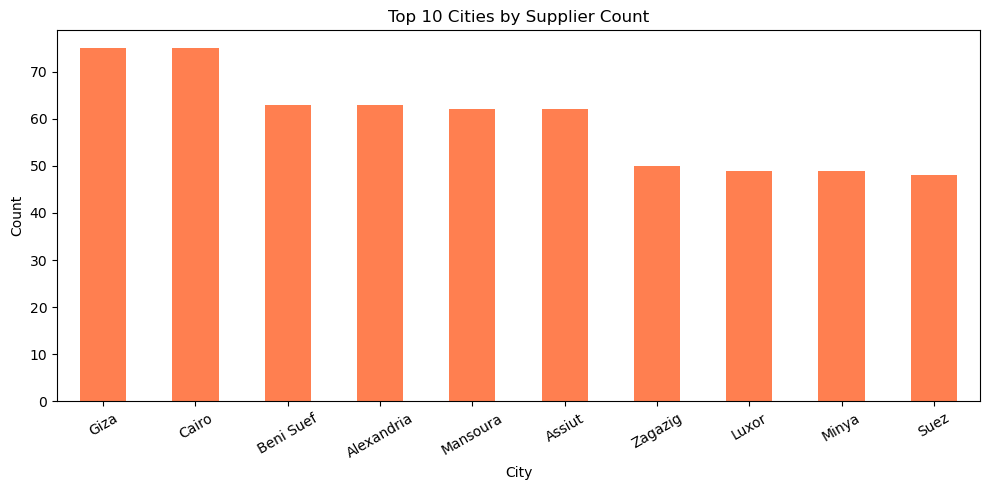

In [69]:
## Top 10 Cities by Supplier Count
plt.figure(figsize=(10,5))
df['city'].value_counts().head(10).plot(kind='bar', color='coral')
plt.title('Top 10 Cities by Supplier Count')
plt.xlabel('City')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

C:\Users\Mariam\AppData\Local\Temp\ipykernel_46620\4106227758.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='supplier_status', y='defect_rate_pct', palette='Set3')


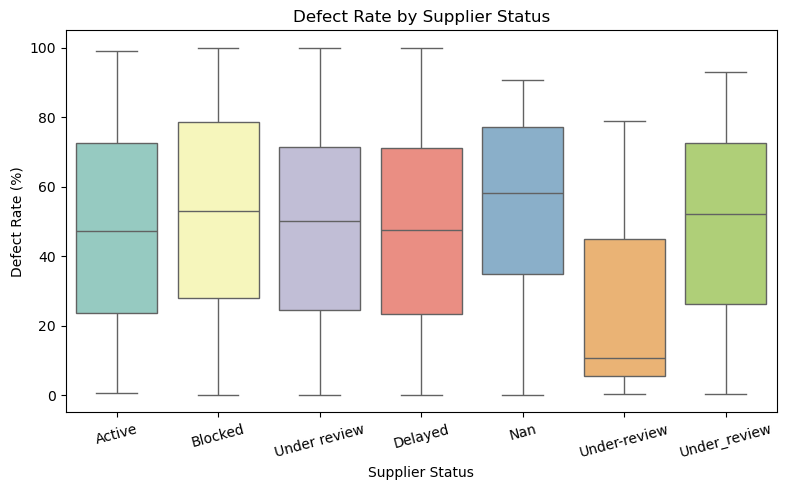

In [71]:
##Defect Rate by Supplier Status
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='supplier_status', y='defect_rate_pct', palette='Set3')
plt.title('Defect Rate by Supplier Status')
plt.xlabel('Supplier Status')
plt.ylabel('Defect Rate (%)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

C:\Users\Mariam\AppData\Local\Temp\ipykernel_46620\3023910376.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='quality_rating', palette='Blues_d')


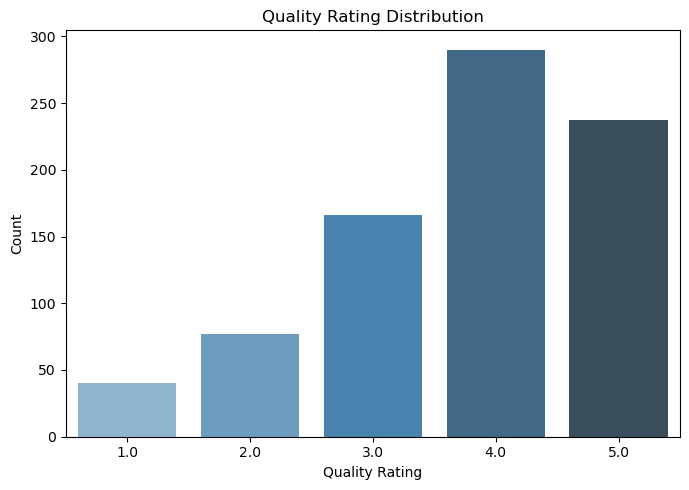

In [73]:
## Quality Rating Distribution
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='quality_rating', palette='Blues_d')
plt.title('Quality Rating Distribution')
plt.xlabel('Quality Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

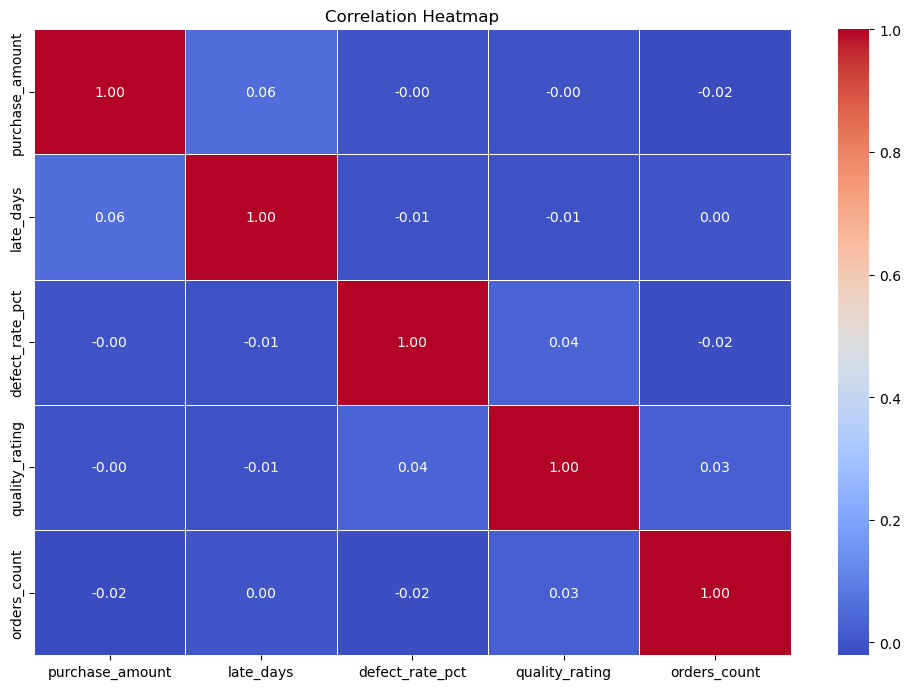

In [75]:
##Correlation Heatmap
plt.figure(figsize=(10,7))
numeric_cols = df[['purchase_amount','late_days','defect_rate_pct','quality_rating','orders_count']]
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

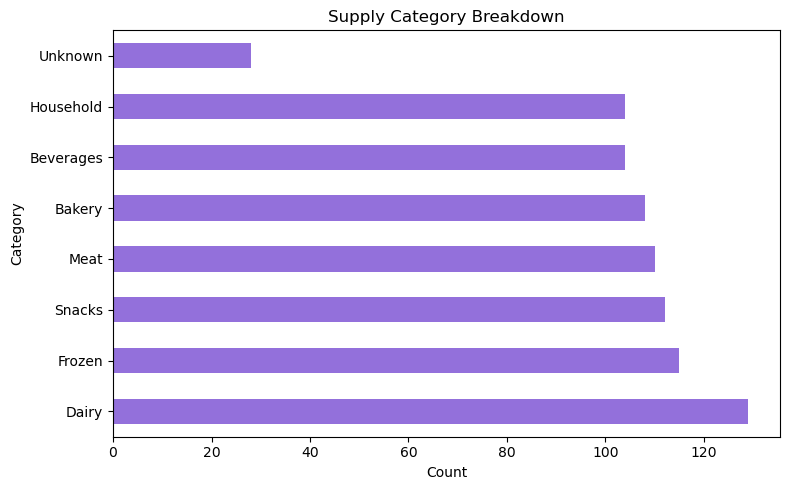

In [77]:
##Supply Category Breakdown
plt.figure(figsize=(8,5))
df['supply_category'].value_counts().plot(kind='barh', color='mediumpurple')
plt.title('Supply Category Breakdown')
plt.xlabel('Count')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

### (From Correlation Heatmap) Expect defect rate and quality rating to be negatively correlated (higher defects = lower rating)
### Late days and defect rate may be positively correlated (delayed suppliers tend to have more defects)

### (From Top Cities Bar)

### Likely Cairo and Giza dominate since they're Egypt's main business hubs
### Smaller cities having suppliers could indicate regional expansion)